## Titanic Dataset Data Cleaning

In [2]:
# importing nessacry libraries

import pandas as pd
import numpy as np

In [4]:
# loading the dataset ( train.xlxs is the titanic dataset)

data = pd.read_excel("train.xlsx")  

In [6]:
# Data Exploration 

print(data.head())                      # First 5 rows
print(data.shape)                      # (rows, columns)
print(data.describe(include='all'))    # Summary statistics

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [8]:
# Identifying missing values

print(data.isnull().sum())

data['Age'] = data['Age'].fillna(data['Age'].mean())  # filling missing age with mean
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0]) # filling missing values

# Droping 'Cabin' coloumn
data.drop(columns='Cabin', inplace=True)



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
# Converting 'Sex' to numeric

data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})

# Creating dummy variables for 'Embarked'

embarked_dummies = pd.get_dummies(data['Embarked'], prefix='Embarked')
data = pd.concat([data, embarked_dummies], axis=1)
data.drop(columns='Embarked', inplace=True)
print(data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked_C  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500       False       False        True  
1          PC 17599  71.2833        True       False       False  
2  STON/O2. 3101282   7.9250       False       False        True  
3            113803  53.1000

In [12]:
# Using IQR for 'Fare' and 'Age'

for col in ['Fare', 'Age']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

In [16]:
# Checking for duplicates

print(data.duplicated().sum())

# Removeing duplicates

data.drop_duplicates(inplace=True)

0


In [18]:
# Creating 'FamilySize'

data['FamilySize'] = data['SibSp'] + data['Parch']

# Extracting 'Title' from 'Name'

data['Title'] = data['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)

In [22]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max Scaling

minmax = MinMaxScaler()
data[['Age', 'Fare', 'FamilySize']] = minmax.fit_transform(data[['Age', 'Fare', 'FamilySize']])
print(data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   

                                           Name  Sex       Age  SibSp  Parch  \
0                       Braund, Mr. Owen Harris    1  0.375000      1      0   
2                        Heikkinen, Miss. Laina    0  0.458333      0      0   
3  Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  0.645833      1      0   
4                      Allen, Mr. William Henry    1  0.645833      0      0   
5                              Moran, Mr. James    1  0.535398      0      0   

             Ticket      Fare  Embarked_C  Embarked_Q  Embarked_S  FamilySize  \
0         A/5 21171  0.111538       False       False        True    0.142857   
2  STON/O2. 3101282  0.121923       False       False        True    0.000000   
3            113803  0.816923       False       False      

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
FamilySize     0
Title          0
dtype: int64
   Sex  Embarked_C  Embarked_Q  Embarked_S
0    1       False       False        True
2    0       False       False        True
3    0       False       False        True
4    1       False       False        True
5    1       False        True       False
              Age        Fare  FamilySize
count  708.000000  708.000000  708.000000
mean     0.509188    0.263617    0.101897
std      0.198560    0.206376    0.193028
min      0.000000    0.000000    0.000000
25%      0.375000    0.121218    0.000000
50%      0.535398    0.172949    0.000000
75%      0.583333    0.392260    0.142857
max      1.000000    1.000000    1.000000


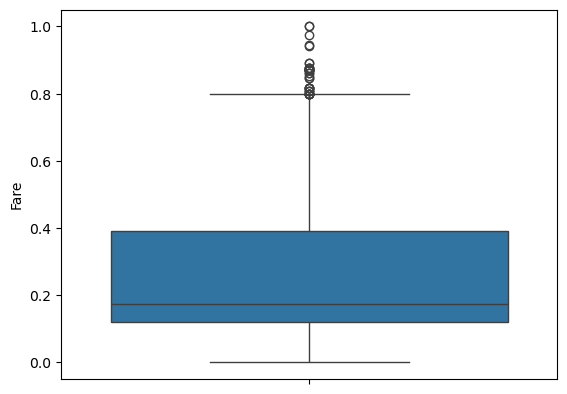

In [24]:
# Checking for missing values

print(data.isnull().sum())

# Checking for outliers 

import seaborn as sns
sns.boxplot(data['Fare'])

# Checking categorical encoding

print(data[['Sex'] + list(embarked_dummies.columns)].head())

# Checking normalization

print(data[['Age', 'Fare', 'FamilySize']].describe())

The dataset has been cleaned and is ready for further visualizations

## Conclusions :

This notebook successfully performs comprehensive data cleaning on the Titanic dataset. The key steps included are:

1. **Handling Missing Values**: Imputed missing Age values with mean and Embarked values with mode. Dropped the Cabin column due to excessive missing data (687 out of 891).

2. **Data Type Conversion**: Converted categorical Sex variable to numeric (male=1, female=0).

3. **Encoding**: Applied one-hot encoding to the Embarked variable, creating binary columns for each port.

4. **Outlier Treatment**: Used IQR method to identify and handle outliers in Age and Fare columns, ensuring data quality.

5. **Duplicate Removal**: Checked and removed duplicate records (0 duplicates found).

6. **Feature Engineering**: Created FamilySize feature by combining SibSp and Parch columns. Extracted Title from passenger names.

7. **Normalization**: Applied Min-Max scaling to Age, Fare, and FamilySize columns, transforming values to 0-1 range.

The cleaned dataset now contains 708 records with no missing values, properly encoded categorical variables, normalized numerical features, and is ready for machine learning model development and further analysis.